In [3]:
import sys, os
dir = os.getcwd()

ext = ['', '/..', '/../src/models', '/../src/nlp', '/../src/synth']
sys.path += [dir + i for i in ext]

In [4]:
from chat import *
from api.football import *
from scene import Scene

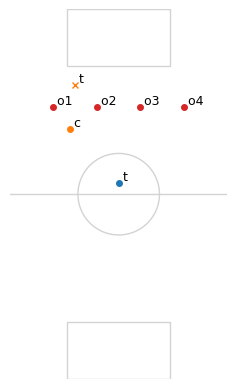

In [5]:
demo1_1 = Scene([
    Coach('C').at(Vector(-4.5, 6)),
    Teammate('T').at(Vector(0, 1)),
    Opponent('O1').at(Vector(-6, 8)),
    Opponent('O2').at(Vector(-2, 8)),
    Opponent('O3').at(Vector(2, 8)),
    Opponent('O4').at(Vector(6, 8)),
    Target('t').at(Vector(-4, 10))
])

plotField(demo1_1, axis=False)

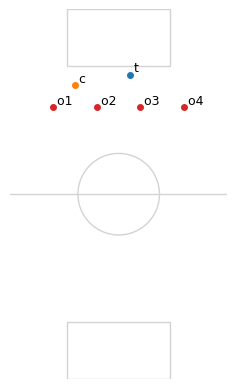

In [6]:
demo1_2 = Scene([
    Coach('C').at(Vector(-4, 10)),
    Teammate('T').at(Vector(1, 11)),
    Opponent('O1').at(Vector(-6, 8)),
    Opponent('O2').at(Vector(-2, 8)),
    Opponent('O3').at(Vector(2, 8)),
    Opponent('O4').at(Vector(6, 8)),
])

plotField(demo1_2, axis=False)

In [6]:
narration1 = "(a) Move past the defending line and prepare to receive the ball, then (b) wait until your teammate is also past the defending line and pass the ball back to him."

In [7]:
demoMap = {
    '1': {
        'a': demo1_1,
        'b': demo1_2
    }
}

In [8]:
narrations = '\n'.join([f"Demo {i + 1}: {n}" for i, n in enumerate([narration1])])
print(narrations)

Demo 1: (a) Move past the defending line and prepare to receive the ball, then (b) wait until your teammate is also past the defending line and pass the ball back to him.


In [9]:
from interpretable import Interpretable
from task import Task

tasks = Task.fromInterpretable(Interpretable(language=narrations))

for t in tasks:
    print(str(t))

Task ID: 0
Objective (what): Move past the defending line and prepare to receive the ball.
Control (how): 
Termination (until): 
Condition (when): 
Task ID: 1
Objective (what): Pass the ball back to your teammate.
Control (how): 
Termination (until): Your teammate is past the defending line.
Condition (when): 


In [10]:
from action import *

act = Act()
actions = Action.fromTask(tasks, actionsAPI)
act.do(actions)

In [11]:
actions

In [12]:
for a in act.actions:
    a.learn(demoMap)

{'logic': 'A AND B', 'constraints': [{'id': 'A', 'api': 'AheadOfLine', 'params': {'obj': 'C', 'height': 'midfield'}}, {'id': 'B', 'api': 'HasAngleOfPass', 'params': {'ref': 't', 'radius': 5.0}}]}


/Library/Frameworks/Python.framework/Versions/3.11/lib/python3.11/site-packages/numpy/core/_methods.py:173: RuntimeWarning: invalid value encountered in subtract
  x = asanyarray(arr - arrmean)


In [13]:
print(act.export())

{
    "actions": [
        {
            "id": "MoveTo",
            "args": {
                "dest": "lambda_dest",
                "until": ""
            },
            "constraints": {
                "lambda_dest": {
                    "logical": "A AND B",
                    "identifiers": [
                        "A",
                        "B"
                    ],
                    "args": {
                        "A": {
                            "id": "AheadOfLine",
                            "args": {
                                "obj": "C",
                                "height": {
                                    "avg": 6.0,
                                    "std": 0.0
                                }
                            }
                        },
                        "B": {
                            "type": "InZone",
                            "args": {
                                "zone": "B4"
                            }
      